In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data= pd.read_csv("iris.csv")
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [15]:
df = data.copy()

In [18]:
df.drop("Id", axis=1, inplace=True, errors="ignore")
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [47]:
df.duplicated().sum()


np.int64(0)

In [48]:
df.shape

(147, 5)

In [49]:
df['Species'].nunique()

3

In [50]:
df.info()

<class 'pandas.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  147 non-null    float64
 1   SepalWidthCm   147 non-null    float64
 2   PetalLengthCm  147 non-null    float64
 3   PetalWidthCm   147 non-null    float64
 4   Species        147 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.9 KB


In [51]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,147.000000,147.000000,147.000000,147.000000
mean,5.856463,3.055782,3.780272,1.208844
std,0.829100,0.437009,1.759111,0.757874
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Text(0.5, 1.0, 'Distribution of Sepal Width')

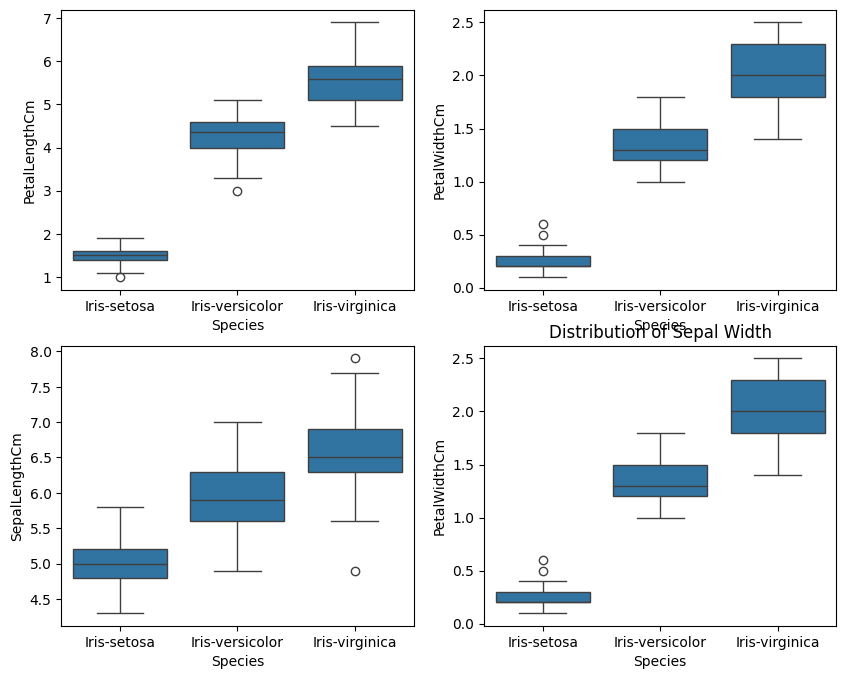

In [46]:
fig, ax=plt.subplots(2,2, figsize=(10,8))
sns.boxplot(x="Species", y="PetalLengthCm", data=df, ax=ax[0,0])
plt.title("Distribution of Petal Length")
sns.boxplot(x="Species", y="PetalWidthCm", data=df, ax=ax[0,1])
plt.title("Distribution of Petal Width")
sns.boxplot(x="Species", y="SepalLengthCm", data=df, ax=ax[1,0])
plt.title("Distribution of Sepal Length")
sns.boxplot(x="Species", y="PetalWidthCm", data=df, ax=ax[1,1])
plt.title("Distribution of Sepal Width")

<Axes: xlabel='PetalLengthCm', ylabel='PetalWidthCm'>

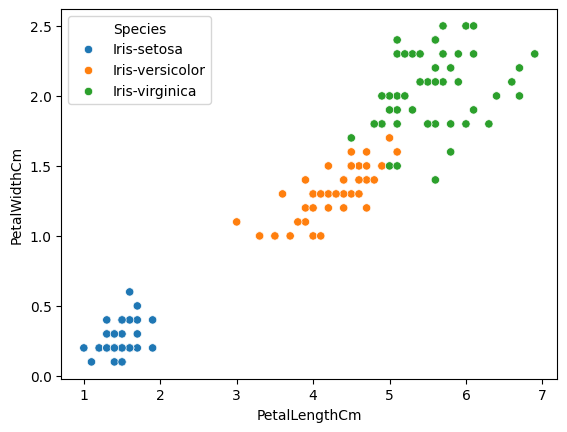

In [39]:
sns.scatterplot(x="PetalLengthCm", y="PetalWidthCm", hue="Species", data=df)

<Axes: xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

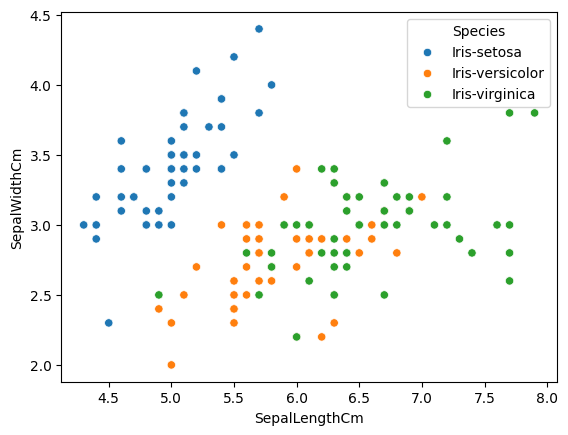

In [40]:
sns.scatterplot(x="SepalLengthCm", y="SepalWidthCm", hue="Species", data=df)

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

In [58]:
X= df.drop("Species", axis=1)
Y= df["Species"]

In [59]:
X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size=0.2, random_state=42)
model= LogisticRegression()
model.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [62]:
y_pred= model.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, y_pred) * 100)
print("Precision:", precision_score(Y_test, y_pred, average="weighted") * 100)
print("Recall:", recall_score(Y_test, y_pred, average="weighted") * 100)
print("F1 Score:", f1_score(Y_test, y_pred, average="weighted") * 100)

Accuracy: 93.33333333333333
Precision: 93.33333333333333
Recall: 93.33333333333333
F1 Score: 93.33333333333333


In [64]:
classification_rep= classification_report(Y_test, y_pred)
print(classification_rep)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.89      0.89      0.89         9

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



<Axes: >

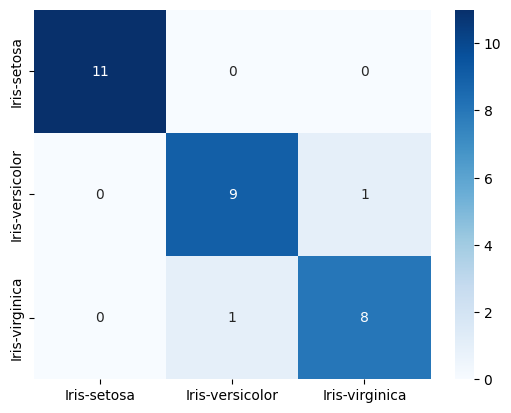

In [66]:
cm= confusion_matrix(Y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)

In [67]:
cm

array([[11,  0,  0],
       [ 0,  9,  1],
       [ 0,  1,  8]])

In [77]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
x= df.drop("Species", axis=1)
y= df["Species"]
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42)
scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)
knn_model= KNeighborsClassifier(n_neighbors=3)
knn_model.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [78]:
y_pred= knn_model.predict(x_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred) * 100)
print("Precision:", precision_score(y_test, y_pred, average="weighted") * 100)
print("Recall:", recall_score(y_test, y_pred, average="weighted") * 100)
print("F1 Score:", f1_score(y_test, y_pred, average="weighted") * 100)

Accuracy: 93.33333333333333
Precision: 93.33333333333333
Recall: 93.33333333333333
F1 Score: 93.33333333333333


In [ ]:
knn_model= KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)
y_pred= knn_model.predict(x_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred) * 100)
print("Precision:", precision_score(y_test, y_pred, average="weighted") * 100)
print("Recall:", recall_score(y_test, y_pred, average="weighted") * 100)
print("F1 Score:", f1_score(y_test, y_pred, average="weighted") * 100)

Accuracy: 93.33333333333333
Precision: 93.33333333333333
Recall: 93.33333333333333
F1 Score: 93.33333333333333


In [71]:
knn_model= KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, Y_train)
y_pred= knn_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(Y_test, y_pred) * 100)
print("Precision:", precision_score(Y_test, y_pred, average="weighted") * 100)
print("Recall:", recall_score(Y_test, y_pred, average="weighted") * 100)
print("F1 Score:", f1_score(Y_test, y_pred, average="weighted") * 100)

Accuracy: 93.33333333333333
Precision: 93.33333333333333
Recall: 93.33333333333333
F1 Score: 93.33333333333333


In [72]:
for k in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, Y_train)
    acc = accuracy_score(Y_test, knn.predict(X_test_scaled))
    print(f"k={k}  Accuracy={acc*100:.2f}")

k=1  Accuracy=90.00
k=2  Accuracy=93.33
k=3  Accuracy=93.33
k=4  Accuracy=93.33
k=5  Accuracy=93.33
k=6  Accuracy=93.33
k=7  Accuracy=93.33
k=8  Accuracy=93.33
k=9  Accuracy=93.33
k=10  Accuracy=93.33
k=11  Accuracy=93.33
k=12  Accuracy=93.33
k=13  Accuracy=93.33
k=14  Accuracy=93.33


In [75]:
from sklearn.model_selection import GridSearchCV
knn_model= KNeighborsClassifier()
param_grid= {"n_neighbors": list(range(1, 15))}
gridcv= GridSearchCV(knn_model, param_grid, cv=5, scoring="accuracy")
gridcv.fit(X_train_scaled, Y_train)
y_pred= gridcv.predict(X_test_scaled)
print("Accuracy:", accuracy_score(Y_test, y_pred) * 100)
print("Best Parameters:", gridcv.best_params_)

Accuracy: 93.33333333333333
Best Parameters: {'n_neighbors': 9}


In [76]:
res= pd.DataFrame(gridcv.cv_results_)
res

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002828,0.000698,0.004014,0.000628,1,{'n_neighbors': 1},0.958333,0.958333,0.913043,1.0,1.000000,0.965942,0.032354,3
1,0.001384,0.000378,0.002538,0.000524,2,{'n_neighbors': 2},0.958333,0.958333,0.869565,1.0,0.913043,0.939855,0.044631,13
2,0.001292,0.000401,0.007406,0.009580,3,{'n_neighbors': 3},0.958333,0.958333,0.913043,1.0,1.000000,0.965942,0.032354,3
3,0.001789,0.000575,0.002713,0.000495,4,{'n_neighbors': 4},1.000000,0.958333,0.869565,1.0,0.956522,0.956884,0.047634,10
4,0.001153,0.000118,0.002381,0.000449,5,{'n_neighbors': 5},1.000000,0.958333,0.826087,1.0,0.913043,0.939493,0.065173,14
5,0.001266,0.000392,0.002500,0.000311,6,{'n_neighbors': 6},1.000000,0.958333,0.869565,1.0,0.956522,0.956884,0.047634,10
6,0.001068,0.000149,0.004858,0.005605,7,{'n_neighbors': 7},1.000000,0.958333,0.869565,1.0,0.956522,0.956884,0.047634,10
7,0.001397,0.000398,0.002913,0.000714,8,{'n_neighbors': 8},1.000000,0.958333,0.913043,1.0,0.956522,0.965580,0.032447,5
8,0.001230,0.000441,0.002363,0.000453,9,{'n_neighbors': 9},1.000000,0.958333,0.956522,1.0,1.000000,0.982971,0.020864,1
9,0.001094,0.000239,0.002685,0.001287,10,{'n_neighbors': 10},1.000000,0.958333,0.913043,1.0,1.000000,0.974275,0.034609,2


In [79]:
from sklearn.naive_bayes import GaussianNB
nb_model= GaussianNB()
nb_model.fit(x_train_scaled, y_train)
y_pred_nb= nb_model.predict(x_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred_nb) * 100)
print("Precision:", precision_score(y_test, y_pred_nb, average="weighted") * 100)
print("Recall:", recall_score(y_test, y_pred_nb, average="weighted") * 100)
print("F1 Score:", f1_score(y_test, y_pred_nb, average="weighted") * 100)

Accuracy: 96.66666666666667
Precision: 96.96969696969695
Recall: 96.66666666666667
F1 Score: 96.64799253034548


In [80]:
from sklearn.pipeline import Pipeline
pipeline= Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])